# Baseline e Política Adaptativa — Thompson Sampling

## Objetivo

Este notebook implementa e compara uma política determinística utilizada como baseline com uma estratégia adaptativa baseada em **Thompson Sampling**.

A solução considera:

- **Braços:** `cellular` e `telephone`;
- **Recompensa:** conversão binária (`reward`);
- **Contexto:** selecionado experimentalmente utilizando apenas o conjunto de validação;
- **Avaliação:** replay offline sobre dados históricos.

Como a base contém apenas a recompensa associada à ação que realmente ocorreu, uma recompensa só pode ser observada quando a ação escolhida pela política coincide com a ação registrada historicamente.

Para evitar utilizar o conjunto de teste durante decisões de modelagem, a sequência de dados é dividida temporalmente em:

- 60% para treinamento;
- 20% para validação e seleção do contexto;
- 20% para avaliação final.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Carregamento da base processada

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "bank_marketing_processed.csv"
)

df = pd.read_csv(DATA_PATH)

print(f"Registros: {len(df)}")
print(f"Colunas: {df.shape[1]}")

df.head()

Registros: 41176
Colunas: 23


,interaction_id,age,job,marital,education,default,housing,loan,month,day_of_week,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,reward,arm,previously_contacted,pdays_since_previous,age_group
0,0,56,housemaid,married,basic.4y,no,no,no,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,0,telephone,0,NaN,50_59
1,1,57,services,married,high.school,unknown,no,no,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,0,telephone,0,NaN,50_59
2,2,37,services,married,high.school,no,yes,no,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,0,telephone,0,NaN,30_39
3,3,40,admin.,married,basic.6y,no,no,no,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,0,telephone,0,NaN,40_49
4,4,56,services,married,high.school,no,no,yes,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,0,telephone,0,NaN,50_59


## 2. Preservação da ordem temporal

O `interaction_id` criado durante o pré-processamento preserva a posição original de cada interação.

Como uma política adaptativa aprende sequencialmente, a base não será embaralhada.

In [3]:
df = (
    df
    .sort_values("interaction_id")
    .reset_index(drop=True)
)

print("Ordem temporal preservada:", df["interaction_id"].is_monotonic_increasing)

Ordem temporal preservada: True


## 3. Contextos candidatos

O primeiro experimento do projeto considerou `age_group + poutcome` como contexto. Como a política adaptativa não superou o baseline nessa configuração inicial, a escolha do contexto passa a ser tratada como uma decisão experimental.

Serão avaliadas alternativas simples e interpretáveis:

- `age_group`;
- `poutcome`;
- `age_group + poutcome`;
- `previous_group`.

A variável `previous_group` resume a quantidade de contatos anteriores em três grupos:

- `none`: nenhum contato anterior;
- `one`: um contato anterior;
- `two_plus`: dois ou mais contatos anteriores.

A seleção será feita **somente no conjunto de validação**.

In [4]:
df["age_context"] = df["age_group"].astype(str)

df["poutcome_context"] = df["poutcome"].astype(str)

df["age_poutcome_context"] = (
    df["age_group"].astype(str)
    + "|"
    + df["poutcome"].astype(str)
)

df["previous_group"] = pd.cut(
    df["previous"],
    bins=[-1, 0, 1, np.inf],
    labels=["none", "one", "two_plus"]
)

df["previous_group_context"] = df["previous_group"].astype(str)

df[
    [
        "age_group",
        "poutcome",
        "previous",
        "previous_group",
        "age_poutcome_context"
    ]
].head()

,age_group,poutcome,previous,previous_group,age_poutcome_context
0,50_59,nonexistent,0,none,50_59|nonexistent
1,50_59,nonexistent,0,none,50_59|nonexistent
2,30_39,nonexistent,0,none,30_39|nonexistent
3,40_49,nonexistent,0,none,40_49|nonexistent
4,50_59,nonexistent,0,none,50_59|nonexistent


## 4. Divisão temporal — treino, validação e teste

In [5]:
train_end = int(len(df) * 0.60)
validation_end = int(len(df) * 0.80)

train_df = df.iloc[:train_end].copy()
validation_df = df.iloc[train_end:validation_end].copy()
test_df = df.iloc[validation_end:].copy()

print(f"Treino: {len(train_df)}")
print(f"Validação: {len(validation_df)}")
print(f"Teste: {len(test_df)}")

Treino: 24705
Validação: 8235
Teste: 8236


Essa separação mantém a ordem original das interações:

`treino → validação → teste`

O conjunto de validação será utilizado para selecionar o contexto da política. O teste ficará reservado para a comparação final.

## 5. Política baseline

A política baseline utiliza uma regra determinística simples:

> escolher sempre o braço com maior taxa de conversão no histórico disponível.

Essa estratégia representa uma política fixa que não personaliza a decisão de acordo com o contexto do cliente.

In [6]:
def get_best_historical_arm(history_df):
    performance = (
        history_df
        .groupby("arm")["reward"]
        .agg(["count", "sum", "mean"])
        .rename(
            columns={
                "count": "interactions",
                "sum": "conversions",
                "mean": "conversion_rate"
            }
        )
    )

    best_arm = performance["conversion_rate"].idxmax()

    return best_arm, performance


def evaluate_baseline(history_df, evaluation_df):
    best_arm, performance = get_best_historical_arm(history_df)

    matches = evaluation_df[
        evaluation_df["arm"] == best_arm
    ].copy()

    conversion_rate = matches["reward"].mean()
    coverage = len(matches) / len(evaluation_df)

    return {
        "arm": best_arm,
        "conversion_rate": conversion_rate,
        "coverage": coverage,
        "evaluated_interactions": len(matches),
        "conversions": int(matches["reward"].sum()),
        "historical_performance": performance
    }

In [7]:
baseline_validation = evaluate_baseline(
    train_df,
    validation_df
)

baseline_validation["historical_performance"]

,interactions,conversions,conversion_rate
arm,,,
cellular,11249,656,0.058316
telephone,13456,532,0.039536


In [8]:
print(f"Braço escolhido pelo baseline: {baseline_validation['arm']}")
print(
    f"Taxa de conversão na validação: "
    f"{baseline_validation['conversion_rate'] * 100:.2f}%"
)
print(
    f"Cobertura do replay na validação: "
    f"{baseline_validation['coverage'] * 100:.2f}%"
)

Braço escolhido pelo baseline: cellular
Taxa de conversão na validação: 11.32%
Cobertura do replay na validação: 92.80%


## 6. Thompson Sampling

A política adaptativa utiliza uma abordagem **Beta-Bernoulli**.

Para cada combinação entre contexto e braço, são mantidos os parâmetros:

- `alpha`: sucessos observados + prior;
- `beta`: fracassos observados + prior.

O prior utilizado é:

`Beta(1, 1)`

Esse prior é uniforme e não estabelece preferência inicial por nenhum braço.

A cada interação, o Thompson Sampling sorteia uma amostra da distribuição posterior de cada braço e seleciona aquele com maior valor amostrado. Dessa forma, a exploração surge naturalmente da incerteza das distribuições.

In [9]:
def run_thompson_replay(
    history_df,
    evaluation_df,
    context_column,
    seed=42,
    return_decisions=False
):
    arms = sorted(history_df["arm"].unique())

    alpha = {}
    beta = {}

    # Inicialização dos priors para contextos observados no histórico
    for context in history_df[context_column].astype(str).unique():
        for arm in arms:
            alpha[(context, arm)] = 1
            beta[(context, arm)] = 1

    # Atualização inicial com os dados históricos
    for context, arm, reward in history_df[
        [context_column, "arm", "reward"]
    ].itertuples(index=False, name=None):

        context = str(context)
        key = (context, arm)

        if key not in alpha:
            alpha[key] = 1
            beta[key] = 1

        alpha[key] += reward
        beta[key] += 1 - reward

    rng = np.random.default_rng(seed)

    decisions = []

    for (
        interaction_id,
        context,
        historical_arm,
        historical_reward
    ) in evaluation_df[
        [
            "interaction_id",
            context_column,
            "arm",
            "reward"
        ]
    ].itertuples(index=False, name=None):

        context = str(context)

        sampled_rewards = {}
        posterior_means = {}

        for arm in arms:
            key = (context, arm)

            # Contextos não observados no histórico começam com Beta(1, 1)
            if key not in alpha:
                alpha[key] = 1
                beta[key] = 1

            posterior_means[arm] = (
                alpha[key]
                / (alpha[key] + beta[key])
            )

            sampled_rewards[arm] = rng.beta(
                alpha[key],
                beta[key]
            )

        chosen_arm = max(
            sampled_rewards,
            key=sampled_rewards.get
        )

        greedy_arm = max(
            posterior_means,
            key=posterior_means.get
        )

        matched = chosen_arm == historical_arm

        observed_reward = (
            int(historical_reward)
            if matched
            else np.nan
        )

        # Só é possível atualizar a política quando a ação escolhida
        # coincide com a ação histórica e a recompensa é observável.
        if matched:
            key = (context, chosen_arm)

            alpha[key] += observed_reward
            beta[key] += 1 - observed_reward

        decisions.append({
            "interaction_id": interaction_id,
            "context": context,
            "historical_arm": historical_arm,
            "chosen_arm": chosen_arm,
            "matched": matched,
            "reward": observed_reward,
            "greedy_arm": greedy_arm,
            "choice_type": (
                "greedy_choice"
                if chosen_arm == greedy_arm
                else "non_greedy_choice"
            )
        })

    results = pd.DataFrame(decisions)

    matches = results[
        results["matched"]
    ].copy()

    metrics = {
        "conversion_rate": matches["reward"].mean(),
        "coverage": len(matches) / len(evaluation_df),
        "evaluated_interactions": len(matches),
        "conversions": int(matches["reward"].sum()),
        "non_greedy_rate": (
            (results["choice_type"] == "non_greedy_choice").mean()
        )
    }

    if return_decisions:
        return metrics, results

    return metrics

### Interpretação de exploração

O Thompson Sampling não possui uma etapa explícita chamada “explorar” ou “explotar”.

Para fins de análise, uma escolha é classificada como `non_greedy_choice` quando o braço sorteado pelo Thompson Sampling é diferente daquele que possuía a maior média posterior naquele momento.

Essa medida é utilizada apenas como aproximação do comportamento exploratório.

## 7. Seleção do contexto no conjunto de validação

In [10]:
CONTEXT_CANDIDATES = {
    "age_group": "age_context",
    "poutcome": "poutcome_context",
    "age_group + poutcome": "age_poutcome_context",
    "previous_group": "previous_group_context"
}

VALIDATION_SEEDS = list(range(20))
MIN_REPLAY_COVERAGE = 0.70

context_results = []

for context_name, context_column in CONTEXT_CANDIDATES.items():

    runs = [
        run_thompson_replay(
            train_df,
            validation_df,
            context_column=context_column,
            seed=seed
        )
        for seed in VALIDATION_SEEDS
    ]

    context_results.append({
        "context": context_name,
        "context_column": context_column,
        "mean_conversion_rate": np.mean(
            [run["conversion_rate"] for run in runs]
        ),
        "std_conversion_rate": np.std(
            [run["conversion_rate"] for run in runs]
        ),
        "mean_coverage": np.mean(
            [run["coverage"] for run in runs]
        )
    })

context_validation = (
    pd.DataFrame(context_results)
    .sort_values(
        "mean_conversion_rate",
        ascending=False
    )
    .reset_index(drop=True)
)

context_validation

,context,context_column,mean_conversion_rate,std_conversion_rate,mean_coverage
0,previous_group,previous_group_context,0.119656,0.000937,0.770370
1,age_group + poutcome,age_poutcome_context,0.119562,0.001354,0.756922
2,poutcome,poutcome_context,0.117492,0.001616,0.779982
3,age_group,age_context,0.113198,0.000153,0.927067


In [11]:
context_validation["conversion_rate_pct"] = (
    context_validation["mean_conversion_rate"] * 100
)

context_validation["coverage_pct"] = (
    context_validation["mean_coverage"] * 100
)

context_validation[
    [
        "context",
        "conversion_rate_pct",
        "std_conversion_rate",
        "coverage_pct"
    ]
]

,context,conversion_rate_pct,std_conversion_rate,coverage_pct
0,previous_group,11.965615,0.000937,77.037037
1,age_group + poutcome,11.956170,0.001354,75.692168
2,poutcome,11.749184,0.001616,77.998179
3,age_group,11.319817,0.000153,92.706740


Para evitar selecionar uma configuração com taxa de conversão alta baseada em uma quantidade muito pequena de interações observáveis, é exigida uma cobertura mínima de replay de **70%**.

Entre os contextos que atendem a esse critério, é selecionado aquele com maior taxa média de conversão na validação.

In [12]:
eligible_contexts = context_validation[
    context_validation["mean_coverage"] >= MIN_REPLAY_COVERAGE
].copy()

if eligible_contexts.empty:
    raise ValueError(
        "Nenhum contexto atingiu a cobertura mínima definida."
    )

selected_context_row = eligible_contexts.iloc[0]

selected_context_name = selected_context_row["context"]
selected_context_column = selected_context_row["context_column"]

print(f"Contexto selecionado: {selected_context_name}")
print(
    f"Taxa média de conversão na validação: "
    f"{selected_context_row['mean_conversion_rate'] * 100:.2f}%"
)
print(
    f"Cobertura média na validação: "
    f"{selected_context_row['mean_coverage'] * 100:.2f}%"
)

Contexto selecionado: previous_group
Taxa média de conversão na validação: 11.97%
Cobertura média na validação: 77.04%


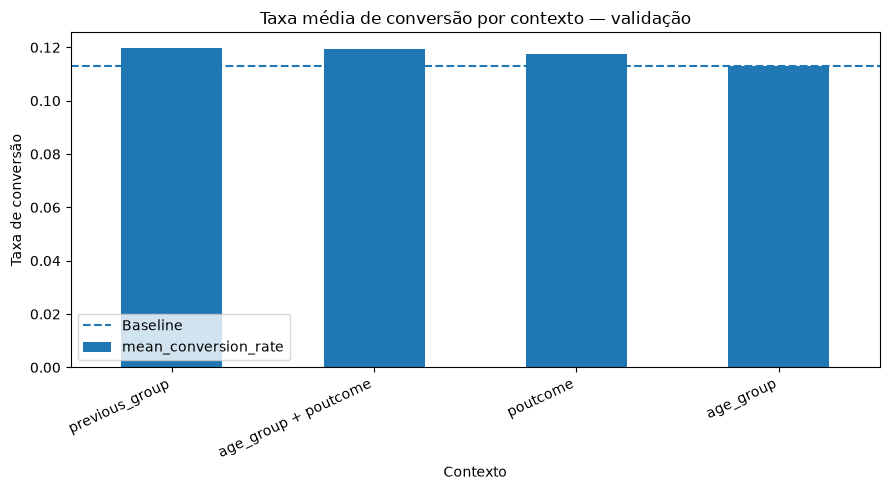

In [13]:
plot_df = context_validation.copy()

plot_df.plot(
    x="context",
    y="mean_conversion_rate",
    kind="bar",
    legend=False,
    figsize=(9, 5)
)

plt.axhline(
    baseline_validation["conversion_rate"],
    linestyle="--",
    label="Baseline"
)

plt.title("Taxa média de conversão por contexto — validação")
plt.xlabel("Contexto")
plt.ylabel("Taxa de conversão")
plt.xticks(rotation=25, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Avaliação final no conjunto de teste

Após a seleção do contexto utilizando somente o conjunto de validação, os dados de treino e validação são reunidos como histórico disponível.

O conjunto de teste permanece separado e é utilizado apenas para a comparação final.

In [14]:
history_final_df = pd.concat(
    [train_df, validation_df],
    ignore_index=True
)

print(f"Histórico final: {len(history_final_df)}")
print(f"Teste final: {len(test_df)}")

Histórico final: 32940
Teste final: 8236


### Baseline final

In [15]:
baseline_test = evaluate_baseline(
    history_final_df,
    test_df
)

print(f"Braço do baseline: {baseline_test['arm']}")
print(
    f"Taxa de conversão: "
    f"{baseline_test['conversion_rate'] * 100:.2f}%"
)
print(
    f"Cobertura do replay: "
    f"{baseline_test['coverage'] * 100:.2f}%"
)
print(
    f"Interações avaliadas: "
    f"{baseline_test['evaluated_interactions']}"
)
print(
    f"Conversões observadas: "
    f"{baseline_test['conversions']}"
)

Braço do baseline: cellular
Taxa de conversão: 32.18%
Cobertura do replay: 87.96%
Interações avaliadas: 7244
Conversões observadas: 2331


### Thompson Sampling final — experimento reproduzível

In [16]:
FINAL_SEED = 42

ts_test, ts_decisions = run_thompson_replay(
    history_final_df,
    test_df,
    context_column=selected_context_column,
    seed=FINAL_SEED,
    return_decisions=True
)

print(f"Contexto: {selected_context_name}")
print(f"Seed: {FINAL_SEED}")
print(
    f"Taxa de conversão: "
    f"{ts_test['conversion_rate'] * 100:.2f}%"
)
print(
    f"Cobertura do replay: "
    f"{ts_test['coverage'] * 100:.2f}%"
)
print(
    f"Interações avaliadas: "
    f"{ts_test['evaluated_interactions']}"
)
print(
    f"Conversões observadas: "
    f"{ts_test['conversions']}"
)
print(
    f"Escolhas não greedy: "
    f"{ts_test['non_greedy_rate'] * 100:.2f}%"
)

Contexto: previous_group
Seed: 42
Taxa de conversão: 33.12%
Cobertura do replay: 82.75%
Interações avaliadas: 6815
Conversões observadas: 2257
Escolhas não greedy: 5.82%


In [17]:
ts_decisions["chosen_arm"].value_counts()

chosen_arm
cellular     7741
telephone     495
Name: count, dtype: int64

## 9. Comparação final

In [18]:
comparison = pd.DataFrame({
    "policy": [
        "Baseline",
        "Thompson Sampling"
    ],
    "conversion_rate": [
        baseline_test["conversion_rate"],
        ts_test["conversion_rate"]
    ],
    "coverage": [
        baseline_test["coverage"],
        ts_test["coverage"]
    ],
    "evaluated_interactions": [
        baseline_test["evaluated_interactions"],
        ts_test["evaluated_interactions"]
    ],
    "conversions": [
        baseline_test["conversions"],
        ts_test["conversions"]
    ]
})

comparison["conversion_rate_pct"] = (
    comparison["conversion_rate"] * 100
)

comparison["coverage_pct"] = (
    comparison["coverage"] * 100
)

comparison

,policy,conversion_rate,coverage,evaluated_interactions,conversions,conversion_rate_pct,coverage_pct
0,Baseline,0.321784,0.879553,7244,2331,32.178355,87.955318
1,Thompson Sampling,0.331181,0.827465,6815,2257,33.118122,82.746479


In [19]:
gain_percentage_points = (
    ts_test["conversion_rate"]
    - baseline_test["conversion_rate"]
) * 100

relative_gain = (
    (
        ts_test["conversion_rate"]
        / baseline_test["conversion_rate"]
    )
    - 1
) * 100

print(
    f"Ganho absoluto do Thompson Sampling: "
    f"{gain_percentage_points:.2f} pontos percentuais"
)

print(
    f"Ganho relativo do Thompson Sampling: "
    f"{relative_gain:.2f}%"
)

Ganho absoluto do Thompson Sampling: 0.94 pontos percentuais
Ganho relativo do Thompson Sampling: 2.92%


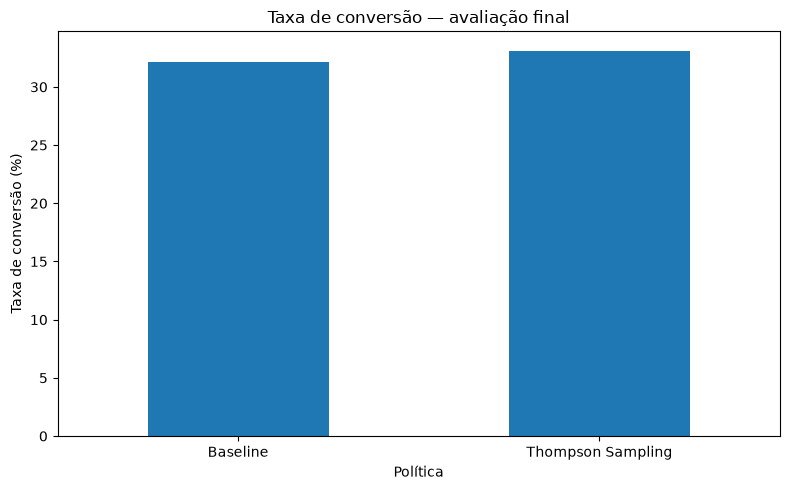

In [20]:
comparison.plot(
    x="policy",
    y="conversion_rate_pct",
    kind="bar",
    legend=False,
    figsize=(8, 5)
)

plt.title("Taxa de conversão — avaliação final")
plt.xlabel("Política")
plt.ylabel("Taxa de conversão (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Robustez em múltiplas seeds

Como Thompson Sampling é estocástico, um único resultado depende da sequência de amostragens aleatórias.

A seed `42` é utilizada como experimento principal reproduzível. Além disso, a política é executada em múltiplas seeds para observar a estabilidade do resultado, sem selecionar a melhor seed.

In [21]:
ROBUSTNESS_SEEDS = list(range(30))

robustness_runs = []

for seed in ROBUSTNESS_SEEDS:
    metrics = run_thompson_replay(
        history_final_df,
        test_df,
        context_column=selected_context_column,
        seed=seed
    )

    robustness_runs.append({
        "seed": seed,
        **metrics
    })

robustness_df = pd.DataFrame(robustness_runs)

print(
    f"Taxa média de conversão: "
    f"{robustness_df['conversion_rate'].mean() * 100:.2f}%"
)

print(
    f"Desvio padrão: "
    f"{robustness_df['conversion_rate'].std() * 100:.2f} p.p."
)

print(
    f"Cobertura média: "
    f"{robustness_df['coverage'].mean() * 100:.2f}%"
)

print(
    f"Baseline final: "
    f"{baseline_test['conversion_rate'] * 100:.2f}%"
)

Taxa média de conversão: 32.42%
Desvio padrão: 0.77 p.p.
Cobertura média: 81.87%
Baseline final: 32.18%


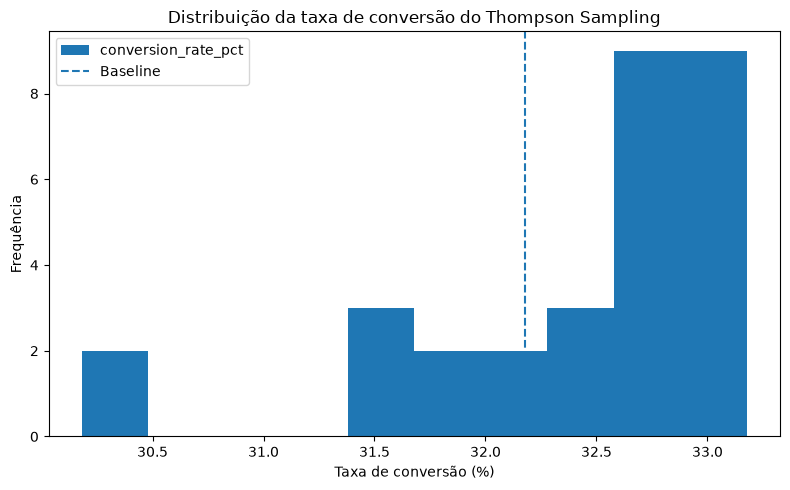

In [22]:
robustness_df["conversion_rate_pct"] = (
    robustness_df["conversion_rate"] * 100
)

robustness_df["conversion_rate_pct"].plot(
    kind="hist",
    bins=10,
    figsize=(8, 5)
)

plt.axvline(
    baseline_test["conversion_rate"] * 100,
    linestyle="--",
    label="Baseline"
)

plt.title("Distribuição da taxa de conversão do Thompson Sampling")
plt.xlabel("Taxa de conversão (%)")
plt.ylabel("Frequência")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Limitações da avaliação offline

A avaliação utiliza dados observacionais históricos e não possui a recompensa contrafactual para ações que não foram realizadas.

Por esse motivo:

- o replay considera apenas interações nas quais a ação escolhida pela política coincide com a ação histórica;
- políticas diferentes podem apresentar coberturas de replay distintas;
- as taxas de conversão devem ser analisadas em conjunto com a cobertura;
- a política histórica responsável pela escolha entre `cellular` e `telephone` não é conhecida como uma política aleatória;
- os resultados não devem ser interpretados como uma estimativa causal exata do desempenho que seria obtido em produção.

Uma avaliação online controlada seria necessária para medir de forma mais rigorosa o impacto real da política.

# Conclusões

O experimento comparou uma política determinística, que seleciona sempre o melhor braço histórico, com uma política adaptativa baseada em Thompson Sampling.

Para evitar que decisões de modelagem fossem influenciadas pelo conjunto de teste, os dados foram separados temporalmente em treino (60%), validação (20%) e teste (20%).

Durante a validação, diferentes alternativas de contexto foram avaliadas. O contexto `previous_group`, que representa a quantidade de contatos realizados em campanhas anteriores, apresentou o melhor desempenho médio entre as alternativas que atendiam ao critério mínimo de cobertura e foi selecionado para a avaliação final.

No conjunto de teste, a política baseline selecionou sempre o braço `cellular` e apresentou taxa de conversão de aproximadamente **32,18%**, com cobertura de replay de **87,96%**.

A política Thompson Sampling, utilizando `previous_group` como contexto e `Beta(1, 1)` como prior, apresentou taxa de conversão de aproximadamente **33,12%**, com cobertura de **82,75%**.

Dessa forma, no experimento principal, a estratégia adaptativa apresentou ganho absoluto de aproximadamente **0,94 ponto percentual** e ganho relativo de aproximadamente **2,92%** em relação ao baseline.

Como Thompson Sampling é uma política estocástica, também foram realizadas execuções com 30 seeds diferentes. A taxa média de conversão obtida foi de aproximadamente **32,42%**, com desvio padrão de **0,77 ponto percentual**, mantendo-se ligeiramente superior ao baseline em média.

Os resultados indicam que a utilização de uma política adaptativa contextual pode apresentar vantagem sobre uma regra fixa. Entretanto, as métricas devem ser interpretadas considerando as limitações do replay offline, especialmente a ausência de recompensas contrafactuais e as diferenças de cobertura entre as políticas.

Uma avaliação online controlada seria necessária para estimar de maneira mais rigorosa o impacto da estratégia em um ambiente de produção.